In [7]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os
from glob import glob
import config as cfg

In [8]:
def get_list_of_files(folder,inputpath):
    
    path = os.path.join( inputpath, folder )
    if not os.path.exists( path ):
        raise RuntimeError( f"No such path {path}" )
    
    files = glob( os.path.join(inputpath, folder, "*.root") )
    if len(files)==0:
        raise RuntimeError( f"No root files found in {path}" )

    return files

def get_list_of_branches(folder,inputpath):
    f0 = get_list_of_files(folder,inputpath)[0]
    try:
        tr = uproot.open( f0+":events" )
        return [ br.name for br in tr.branches ]
    except:
        raise RuntimeError( f"No tree called events found in file {f0}" )

def as_array(folder, varname, cut, nchunks,inputpath):
     # if root files
    if len(glob(os.path.join(os.path.abspath(inputpath), folder, "*.root")))>0:
        if nchunks is not None:
            files = glob(os.path.join(os.path.abspath(inputpath), folder, "*.root"))[:nchunks]
            path = [ f"{f}:events" for f in files ]
        else:
            path = os.path.join( os.path.abspath(inputpath), folder, "*.root:events" )

        try: 
            # awkward array instead of numpy -> allows variable length elements
            #arr = uproot.concatenate( path+":events", expressions=varname, library="np")[varname]
            arr = uproot.concatenate( path, expressions=varname, cut=cut)[varname]
        except:
            branches = get_list_of_branches(folder,inputpath)
            print( f"Branches found in files at path {folder}:" )
            for br in branches:
                print('  ', br)
            raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )

        # Return awkward array as a flattened ndarray
        return ak.to_numpy(ak.ravel(arr))

In [9]:
decays_list = [cfg.sample_allocations[i] for i in ['combined_signal', 'hadronic_background']]
flat_decays_list = [item for sublist in decays_list for item in sublist]

In [10]:
varname = "EVT_hemisEmin_nCharged"
cut = None
nchunks = None
inputpath = "outputs/no_selection"

values = { sample: as_array(sample, varname, cut, nchunks,inputpath) for sample in flat_decays_list }
    

In [15]:
for sample in flat_decays_list:
    print("Length no cuts")
    print(f"{sample}:{len(values[sample])}")

Total length p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:98703
Total length p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:197969
Total length p8_ee_Zbb_ecm91:198069
Total length p8_ee_Zcc_ecm91:199785
Total length p8_ee_Zss_ecm91:212356
Total length p8_ee_Zud_ecm91:199876


In [26]:
# number of events with no preselction (except requiring PV reconstruction) that fail this cut
for sample in flat_decays_list:
    print("Number of events with EVT_hemisEmin_nCharged < 1")
    print(f"{sample}:{sum(values[sample]<1)}")

Number of events with EVT_hemisEmin_nCharged < 1
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:1988
Number of events with EVT_hemisEmin_nCharged < 1
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:3805
Number of events with EVT_hemisEmin_nCharged < 1
p8_ee_Zbb_ecm91:19
Number of events with EVT_hemisEmin_nCharged < 1
p8_ee_Zcc_ecm91:142
Number of events with EVT_hemisEmin_nCharged < 1
p8_ee_Zss_ecm91:223
Number of events with EVT_hemisEmin_nCharged < 1
p8_ee_Zud_ecm91:185


In [29]:
# number of events with preselction [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]

presel_cuts = "(EVT_e < 85) & (EVT_hemisEmin_nLept < 1) & (PV_Rec_vtx_m<40) & (Rec_PV_ntracks>1) & (EVT_hemisEmax_n>10)" 
values_presel = { sample: as_array(sample, varname, presel_cuts, nchunks,inputpath) for sample in flat_decays_list }

In [30]:
for sample in flat_decays_list:
    print("Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]")
    print(f"{sample}:{len(values_presel[sample])}")

Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:90309
Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:181410
Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]
p8_ee_Zbb_ecm91:12048
Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]
p8_ee_Zcc_ecm91:8601
Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]
p8_ee_Zss_ecm91:8990
Length with preseln cuts [except agreement in vertex assignment as this is a bit of a pain and of cour one looking at]
p8_ee_Zud_ecm91:4491


In [31]:
# number of events with no preselction (except requiring PV reconstruction) that fail this cut
for sample in flat_decays_list:
    print("Number of events with EVT_hemisEmin_nCharged < 1 and preseln")
    print(f"{sample}:{sum(values_presel[sample]<1)}")

Number of events with EVT_hemisEmin_nCharged < 1 and preseln
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:1774
Number of events with EVT_hemisEmin_nCharged < 1 and preseln
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:3403
Number of events with EVT_hemisEmin_nCharged < 1 and preseln
p8_ee_Zbb_ecm91:9
Number of events with EVT_hemisEmin_nCharged < 1 and preseln
p8_ee_Zcc_ecm91:73
Number of events with EVT_hemisEmin_nCharged < 1 and preseln
p8_ee_Zss_ecm91:60
Number of events with EVT_hemisEmin_nCharged < 1 and preseln
p8_ee_Zud_ecm91:51


In [32]:
for sample in flat_decays_list:
    print("Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1")
    print(f"{sample}:{sum(values_presel[sample]<1)/len(values_presel[sample])}")


Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:0.01964366785148767
Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:0.018758613086378922
Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1
p8_ee_Zbb_ecm91:0.000747011952191235
Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1
p8_ee_Zcc_ecm91:0.008487385187768865
Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1
p8_ee_Zss_ecm91:0.006674082313681869
Fraction of events that pass preseln that then pass EVT_hemisEmin_nCharged < 1
p8_ee_Zud_ecm91:0.011356045424181697


In [47]:
cuts_for_nochargedreco_SS=  "(EVT_e < 85) & (EVT_hemisEmin_nLept < 1) & (PV_Rec_vtx_m<40) & (Rec_PV_ntracks>1) & (EVT_hemisEmax_n>10)  & (EVT_hemisEmin_nCharged<1) & (Rec_thrustCosTheta>0)"#final filter selects only signal side info 
vars_interest = ["Rec_true_PDG", "Rec_true_M1", "Rec_true_M2", "Rec_true_M1ofM1", "Rec_true_M2ofM1", "Rec_true_M1ofM2", "Rec_true_M2ofM2"]
data = {}
for var in vars_interest:
    data[var] = { sample: as_array(sample, var, cuts_for_nochargedreco_SS, nchunks,inputpath) for sample in flat_decays_list }

In [48]:
data

{'Rec_true_PDG': {'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([ 22.,  22.,  22., ...,  22.,  22., 130.], dtype=float32),
  'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([22., 22., 22., ..., 22., 22., 22.], dtype=float32),
  'p8_ee_Zbb_ecm91': array([   22.,    22.,    22.,    22.,    22.,    22.,    22.,    22.,
            22.,    22.,  -211.,   211.,   130.,   130.,    22.,    22.,
            22.,    22.,    22.,    22.,    22.,    22.,   211.,  -211.,
            22.,    22.,    22.,    22.,    22.,   130.,    22.,    22.,
            22., -2112.,  2112.,    22.,    22.,    22.,    22.,    22.,
            22.,    22.,    22.,    22.,    22.,    22.,   130.,    22.,
            22.,    22.,    22.,    22.,    22.,    22.,    22.,    22.,
            22.,   130.,  -211.,   130.,  -211.,   211.,    22.,    22.,
            22.,    22.,    22.,    22.,    22.,    22.,    22.,    22.,
            22., -2212.,  2112.], dtype=float32),
  'p8_ee_Zcc_ecm91': array([   22.,    22.,    22.,    22.,   

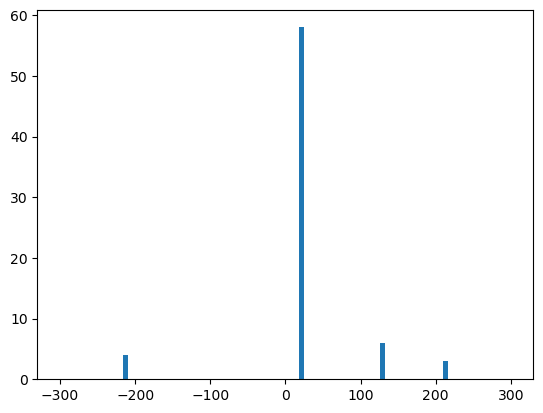

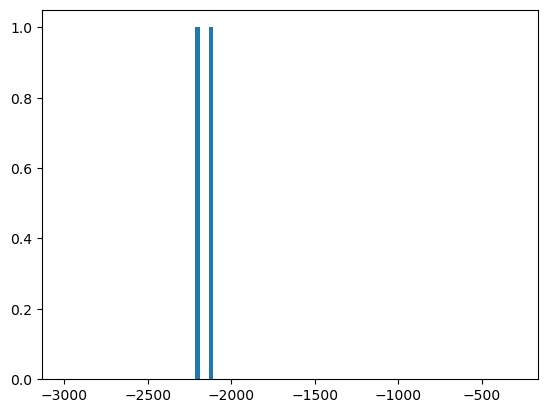

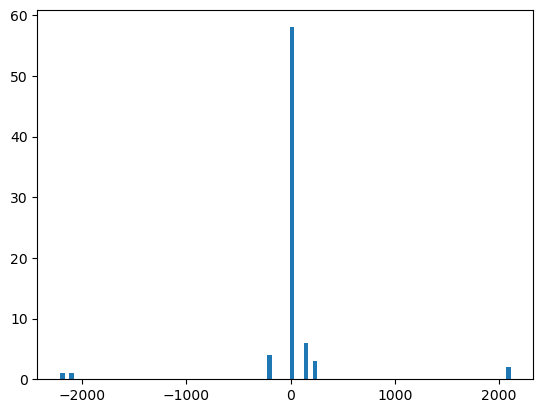

In [82]:
plt.hist(data['Rec_true_PDG']['p8_ee_Zbb_ecm91'], bins=100,range=(-300,300))
plt.show()
plt.hist(data['Rec_true_PDG']['p8_ee_Zbb_ecm91'], bins=100,range=(-3000,-300))
plt.show()
plt.hist(data['Rec_true_PDG']['p8_ee_Zbb_ecm91'], bins=100)
plt.show()

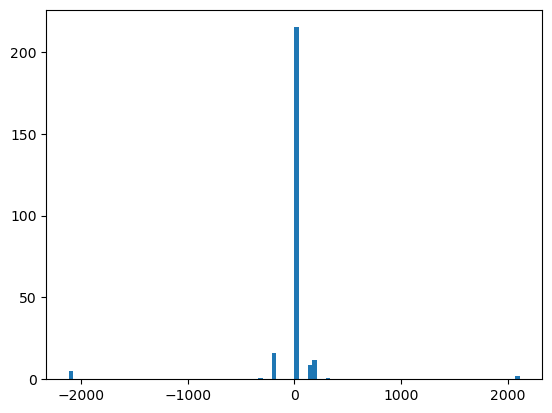

In [67]:
plt.hist(data['Rec_true_PDG']['p8_ee_Zud_ecm91'],bins=100)
plt.show()

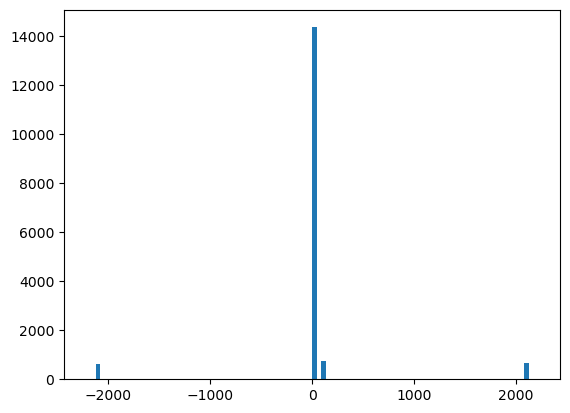

In [74]:
plt.hist(data['Rec_true_PDG']['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],bins=100)
plt.show()

In [69]:
Rec_q = { sample: as_array(sample, "Rec_q", cuts_for_nochargedreco_SS, nchunks,inputpath) for sample in flat_decays_list }

In [70]:
Rec_q

{'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 'p8_ee_Zbb_ecm91': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 'p8_ee_Zcc_ecm91': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [79]:
cuts_for_nochargedreco=  "(EVT_e < 85) & (EVT_hemisEmin_nLept < 1) & (PV_Rec_vtx_m<40) & (Rec_PV_ntracks>1) & (EVT_hemisEmax_n>10)  & (EVT_hemisEmin_nCharged<1) & (EVT_hemisEmin_e<5)"
MCZ_p = { sample: as_array(sample, 'MCZ_p', cuts_for_nochargedreco, nchunks,inputpath) for sample in flat_decays_list }

In [80]:
MCZ_p

{'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([1.8103138e-07, 4.4470719e-01, 5.2543536e-02, ..., 2.7600181e-01,
        1.2792075e-06, 4.5618438e-03], dtype=float32),
 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([9.5728144e-02, 1.9691642e-01, 1.1519843e-03, ..., 1.2781662e-03,
        8.7374923e-07, 2.6630822e-08], dtype=float32),
 'p8_ee_Zbb_ecm91': array([39.87281 , 40.738735, 44.201794], dtype=float32),
 'p8_ee_Zcc_ecm91': array([4.2827003e+01, 4.4007118e+01, 4.2834389e+01, 4.4933178e+01,
        4.2975544e+01, 4.2918968e+01, 4.4337006e+01, 1.7008014e-02,
        4.4636883e+01, 4.5043232e+01, 4.4428265e+01, 4.4068668e+01,
        4.1656128e+01, 4.5037228e+01, 3.9982567e+01, 1.8051608e-06,
        4.4602516e+01, 4.3149662e+01, 3.9499702e+01, 4.4395802e+01,
        3.8767181e+01, 4.3761147e+01, 2.8376692e+01, 4.1907875e+01,
        4.3909260e+01, 4.4890553e+01, 8.8441009e-03, 3.7745800e+01,
        6.1659804e-03, 4.4509708e+01, 4.4835918e+01, 3.9484550e+01,
        4.3767189e+01, 3.9795387e+01

In [81]:
# fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
for sample in flat_decays_list:
    print("fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1")
    print(f"{sample}:{sum(MCZ_p[sample]>1)/len(MCZ_p[sample])}")

fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:0.053064275037369206
fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:0.0480225988700565
fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
p8_ee_Zbb_ecm91:1.0
fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
p8_ee_Zcc_ecm91:0.8913043478260869
fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
p8_ee_Zss_ecm91:0.4666666666666667
fraction of events with SS E<5GeV that pass preseln and fail SS nCharged cut that have MCZ_p>1
p8_ee_Zud_ecm91:0.8518518518518519


In [86]:
# No selection fraction MCZ_p > 1Gev 
MCZ_p_noseln = { sample: as_array(sample, "MCZ_p", None, None,inputpath) for sample in flat_decays_list }
# number of events with no preselction (except requiring PV reconstruction) that fail this cut
for sample in flat_decays_list:
    print("Number of events with MCZ_p >1 Gev")
    print(f"{sample}:{sum(MCZ_p_noseln[sample]>1)}")


for sample in flat_decays_list:
    print("Frac of events with MCZ_p >1 Gev")
    print(f"{sample}:{sum(MCZ_p_noseln[sample]>1)/len(MCZ_p_noseln[sample])}")

Number of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:4450
Number of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:9028
Number of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91:8869
Number of events with MCZ_p >1 Gev
p8_ee_Zcc_ecm91:8947
Number of events with MCZ_p >1 Gev
p8_ee_Zss_ecm91:9623
Number of events with MCZ_p >1 Gev
p8_ee_Zud_ecm91:8950
Frac of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:0.04508474919708621
Frac of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:0.045603099475170356
Frac of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91:0.04477732507358547
Frac of events with MCZ_p >1 Gev
p8_ee_Zcc_ecm91:0.044783141877518334
Frac of events with MCZ_p >1 Gev
p8_ee_Zss_ecm91:0.04531541373919268
Frac of events with MCZ_p >1 Gev
p8_ee_Zud_ecm91:0.04477776221257179


In [87]:
# full pre-selection (except SV location) fraction MCZ_p > 1Gev 
full_presel_cuts = "(EVT_e < 85) & (EVT_hemisEmin_nLept < 1) & (PV_Rec_vtx_m<40) & (Rec_PV_ntracks>1) & (EVT_hemisEmax_n>10)& (EVT_hemisEmin_nCharged>0)" 
MCZ_p_seln = { sample: as_array(sample, "MCZ_p",full_presel_cuts , None,inputpath) for sample in flat_decays_list }

for sample in flat_decays_list:
    print("Number of events with MCZ_p >1 Gev")
    print(f"{sample}:{sum(MCZ_p_seln[sample]>1)}")


for sample in flat_decays_list:
    print("Frac of events with MCZ_p >1 Gev")
    print(f"{sample}:{sum(MCZ_p_seln[sample]>1)/len(MCZ_p_seln[sample])}")

Number of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:4017
Number of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:8091
Number of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91:786
Number of events with MCZ_p >1 Gev
p8_ee_Zcc_ecm91:651
Number of events with MCZ_p >1 Gev
p8_ee_Zss_ecm91:565
Number of events with MCZ_p >1 Gev
p8_ee_Zud_ecm91:313
Frac of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:0.04537188682441972
Frac of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:0.04545326869168066
Frac of events with MCZ_p >1 Gev
p8_ee_Zbb_ecm91:0.06528781460254174
Frac of events with MCZ_p >1 Gev
p8_ee_Zcc_ecm91:0.07633677298311445
Frac of events with MCZ_p >1 Gev
p8_ee_Zss_ecm91:0.06326987681970885
Frac of events with MCZ_p >1 Gev
p8_ee_Zud_ecm91:0.0704954954954955


In [90]:
# full pre-selection (except SV location) fraction MCZ_p > 1Gev 
full_presel_cuts_plusEmine = "(EVT_e < 85) & (EVT_hemisEmin_nLept < 1) & (PV_Rec_vtx_m<40) & (Rec_PV_ntracks>1) & (EVT_hemisEmax_n>10)& (EVT_hemisEmin_nCharged>0) & (EVT_hemisEmin_e<10)" 
MCZ_p_lowe = { sample: as_array(sample, "MCZ_p",full_presel_cuts_plusEmine , None,inputpath) for sample in flat_decays_list }

for sample in flat_decays_list:
    print("Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev")
    print(f"{sample}:{sum(MCZ_p_lowe[sample]>1)/len(MCZ_p_lowe[sample])}")

Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu:0.045030398859764384
Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu:0.044778666423963866
Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev
p8_ee_Zbb_ecm91:0.12727272727272726
Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev
p8_ee_Zcc_ecm91:0.07883817427385892
Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev
p8_ee_Zss_ecm91:0.04451510333863275
Frac of events with hemisEmin_e<10GeV that also have MCZ_p >1 Gev
p8_ee_Zud_ecm91:0.07630522088353414
